## Use Celltypist to annotate cell types

switch to celltypist_env

In [2]:
import scanpy as sc
import anndata as ad
import celltypist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/scratch/user/uqwsuwak/conda_envs/celltypist_env/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [3]:


adata = sc.read_h5ad(
    "/scratch/user/uqwsuwak/sc/new_integration/output/2025_03_04_integration/2026_03_19_master_file.h5ad",
    backed=None
)

In [4]:
adata.obs.head()

,sample,log_counts,sample_id,patient_id,patient_num,location,timepoint,patient_location,_scvi_batch,_scvi_labels,...,tissue_id,batch,biopsy_id,serostatus,pathotype,pathotype2,age,sex,ra_symptom_duration_week,DAS28_CRP
Pt01BL_AP0419_bl_PBMC_filtered_AAACCTGAGATGCGAC-1,AP04_19_PBMC,3.629613,0,Pt01BL,1,PBMC,bl,Pt01BL_PBMC,0,0,...,AP0419,1.1,AP04/19,SeroPos,PI,nonLM,52.0,F,7.0,6.1
Pt01BL_AP0419_bl_PBMC_filtered_AAACCTGAGGCAAAGA-1,AP04_19_PBMC,3.783260,0,Pt01BL,1,PBMC,bl,Pt01BL_PBMC,0,0,...,AP0419,1.1,AP04/19,SeroPos,PI,nonLM,52.0,F,7.0,6.1
Pt01BL_AP0419_bl_PBMC_filtered_AAACCTGAGGGTTTCT-1,AP04_19_PBMC,3.888853,0,Pt01BL,1,PBMC,bl,Pt01BL_PBMC,0,0,...,AP0419,1.1,AP04/19,SeroPos,PI,nonLM,52.0,F,7.0,6.1
Pt01BL_AP0419_bl_PBMC_filtered_AAACCTGAGGTGGGTT-1,AP04_19_PBMC,3.733679,0,Pt01BL,1,PBMC,bl,Pt01BL_PBMC,0,0,...,AP0419,1.1,AP04/19,SeroPos,PI,nonLM,52.0,F,7.0,6.1
Pt01BL_AP0419_bl_PBMC_filtered_AAACCTGCACTGTCGG-1,AP04_19_PBMC,3.683137,0,Pt01BL,1,PBMC,bl,Pt01BL_PBMC,0,0,...,AP0419,1.1,AP04/19,SeroPos,PI,nonLM,52.0,F,7.0,6.1


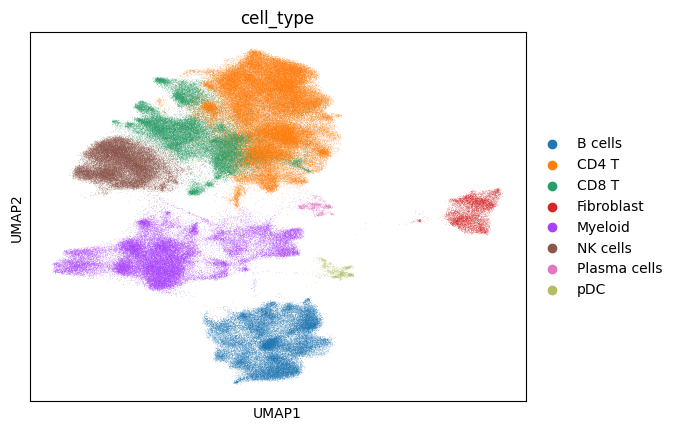

In [5]:
sc.pl.umap(adata, color = "cell_type")

In [7]:
import celltypist
from celltypist import models

# 1. Load model
model = models.Model.load("/QRISdata/Q7458/Projects/xenium/ref/Immune_All_Low.pkl")

# 2. Predict — celltypist expects log1p normalised counts in .X
# If .X is currently latent space, use the counts layer
import scanpy as sc
adata_ct = adata.copy()
adata_ct.X = adata_ct.layers["counts"].copy()
sc.pp.normalize_total(adata_ct, target_sum=1e4)
sc.pp.log1p(adata_ct)

# 3. Run celltypist with majority voting
predictions = celltypist.annotate(
    adata_ct,
    model=model,
    majority_voting=True,
    over_clustering="leiden_scVI"
)

# 4. Transfer predictions back to original adata
adata.obs["ct_predicted"] = predictions.predicted_labels["predicted_labels"]
adata.obs["ct_majority_voting"] = predictions.predicted_labels["majority_voting"]

🔬 Input data has 262341 cells and 16647 genes
🔗 Matching reference genes in the model
🧬 5466 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


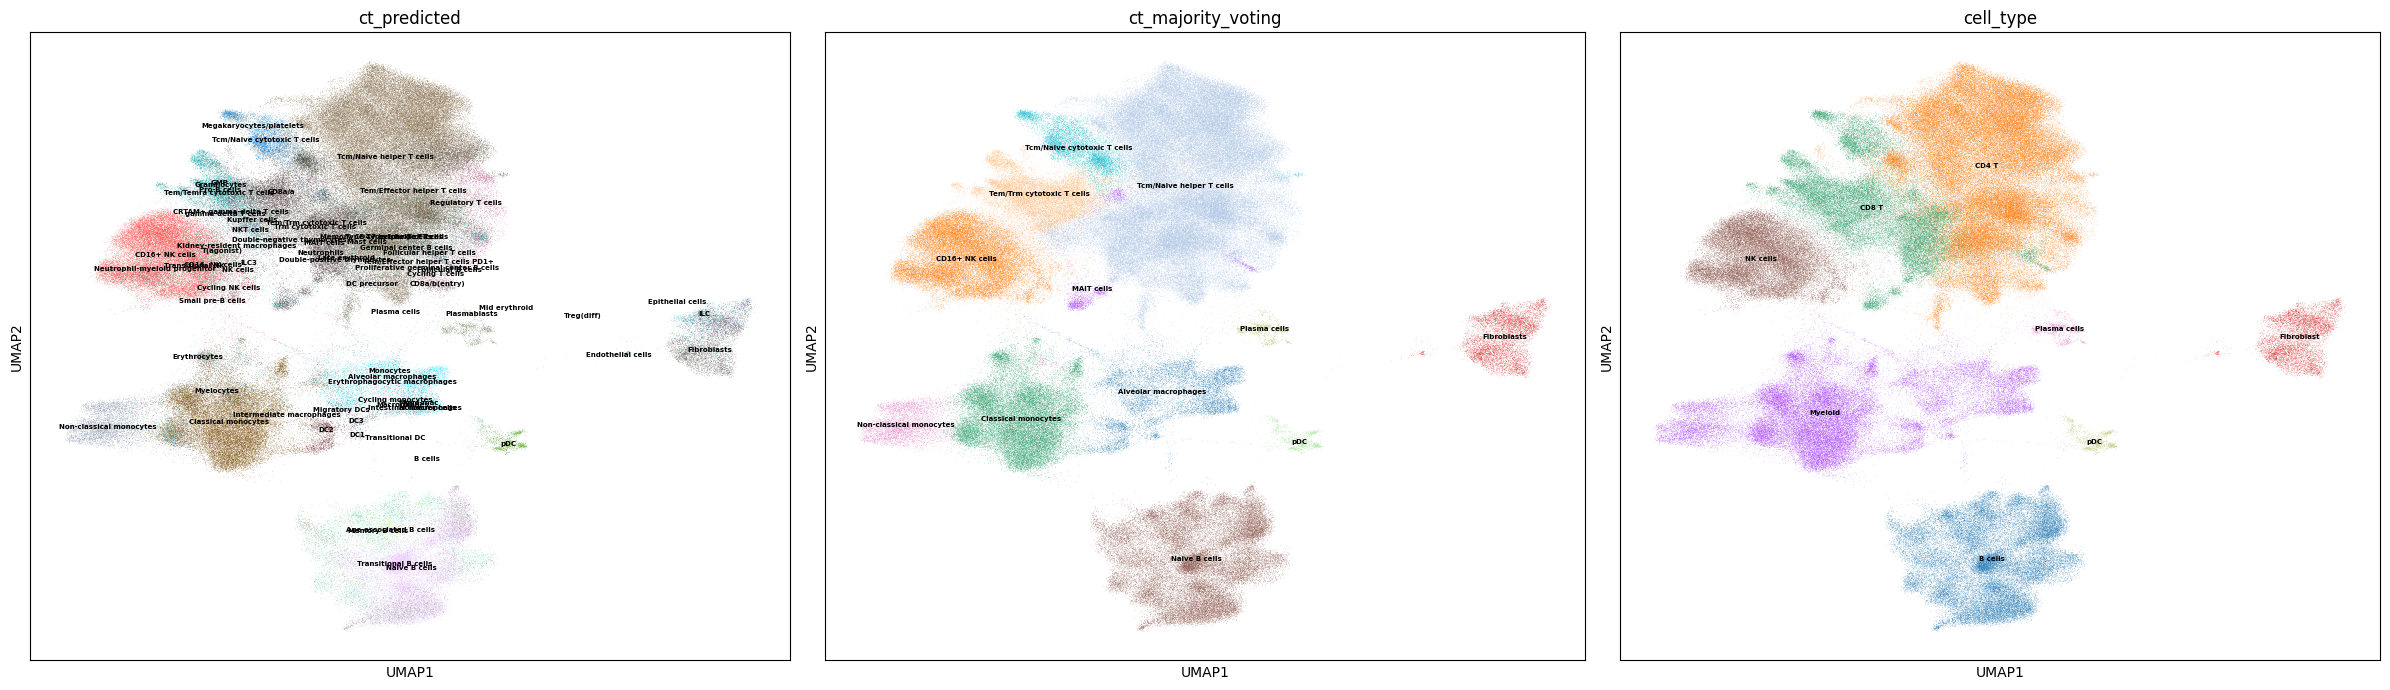

In [8]:
import scanpy as sc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sc.pl.umap(adata, color="ct_predicted",       legend_loc="on data", legend_fontsize=5, title="ct_predicted",        ax=axes[0], show=False)
sc.pl.umap(adata, color="ct_majority_voting", legend_loc="on data", legend_fontsize=5, title="ct_majority_voting", ax=axes[1], show=False)
sc.pl.umap(adata, color="cell_type",          legend_loc="on data", legend_fontsize=5, title="cell_type",          ax=axes[2], show=False)

plt.tight_layout()
plt.savefig("/scratch/user/uqwsuwak/sc/celltypist_umap.pdf", bbox_inches="tight")
plt.show()

In [9]:
adata.write_h5ad("/scratch/user/uqwsuwak/sc/new_integration/output/2025_03_04_integration/2026_03_19_master_file.h5ad")